# Task: Augmentation

**Student Name:** Mykhailo Andrusiak  
**Country:** Switzerland  
**Semester term:** FS26  

## Day 1 - Data and Domain

### Use Case

In the context of automated road sign recognition for Swiss urban traffic management, cameras deployed along Swiss roads capture images of traffic signs to support real-time speed limit enforcement, driver assistance systems, and ASTRA road monitoring infrastructure. These images are processed by sign detection algorithms to identify speed limits and directional information. This use case is particularly relevant for Switzerland because Swiss urban roads combine multiple sign types (speed limits, directional arrows, street names) at single locations, and reliable automated recognition is critical for both traffic safety enforcement and navigation systems.

### Problem Statement

This project addresses the problem of simulating and quantifying atmospheric and sensor degradation in road sign camera images. Cameras used for automated sign recognition frequently experience fog conditions that cause two distinct but simultaneous effects: atmospheric light scattering reduces scene contrast (signs appear washed out toward white), and optical scattering blurs spatial detail. Additionally, reduced photon count under fog and adverse weather introduces sensor noise. Together, these effects cause sign text and numerals to lose contrast and sharpness, reducing the reliability of automated recognition. The speed limit numeral "40" on the circular sign serves as the primary degradation indicator: its high-contrast black strokes on a white background become unreadable at a measurable level of degradation. Augmentation is needed to simulate these conditions systematically and assess at what degradation level automated sign recognition would fail.

### Experimental Objective

The objective of augmentation in this context is to simulate two physically distinct degradation channels experienced by road sign cameras under fog conditions. The first channel is atmospheric degradation: fog simultaneously reduces scene contrast — causing signs to appear washed out toward the ambient fog brightness — and attenuates spatial detail in sign structure, progressively obscuring the boundaries of numerals and text. The second channel is sensor-level degradation: reduced photon count under fog introduces per-pixel intensity perturbations that further obscure character boundaries. By systematically increasing the intensity of both channels across three configurations, we quantify at what level of combined degradation the structural fidelity of the sign image becomes unacceptable for automated recognition, using SSIM as the evaluation measure. The speed limit sign "40" serves as the identifiable reference structure whose legibility anchors the practical interpretation of SSIM values.

### Data Definition, Source, and Visualization

The selected image is a photograph of a Swiss road sign cluster in Cologny, Geneva, showing a speed limit sign "40" (circular, red border, black numeral on white), directional signs ("Chêne", "La Capite / Thonon", "Fondation Martin Bodmer"), and a street name plate ("Rte de La-Capite"). The signs are photographed against a clear sky and building background with good illumination and high contrast. The **identifiable structure** is the speed limit sign "40": its circular geometry, red border, and large black numeral provide sharp, well-defined edges and high local contrast between the dark strokes (intensity ~0.1) and the white sign background (~0.9), yielding a contrast of ~0.80 — making it an ideal reference element for measuring augmentation-induced degradation. Under progressive atmospheric and sensor degradation, this contrast is systematically reduced: fog compresses it toward zero while noise and blur destroy the residual spatial structure, providing a concrete domain-relevant threshold for recognition failure.

**Source:** Wikimedia Commons, CC BY-SA 3.0  
**File:** `File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG`  
**URL:** https://commons.wikimedia.org/wiki/File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG

Source: Wikimedia Commons, CC BY-SA 3.0, File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG
Original shape: (2592, 3872, 3)
Working shape:  (803, 1200), dtype: float64
Intensity range: [0.0082, 0.8974]


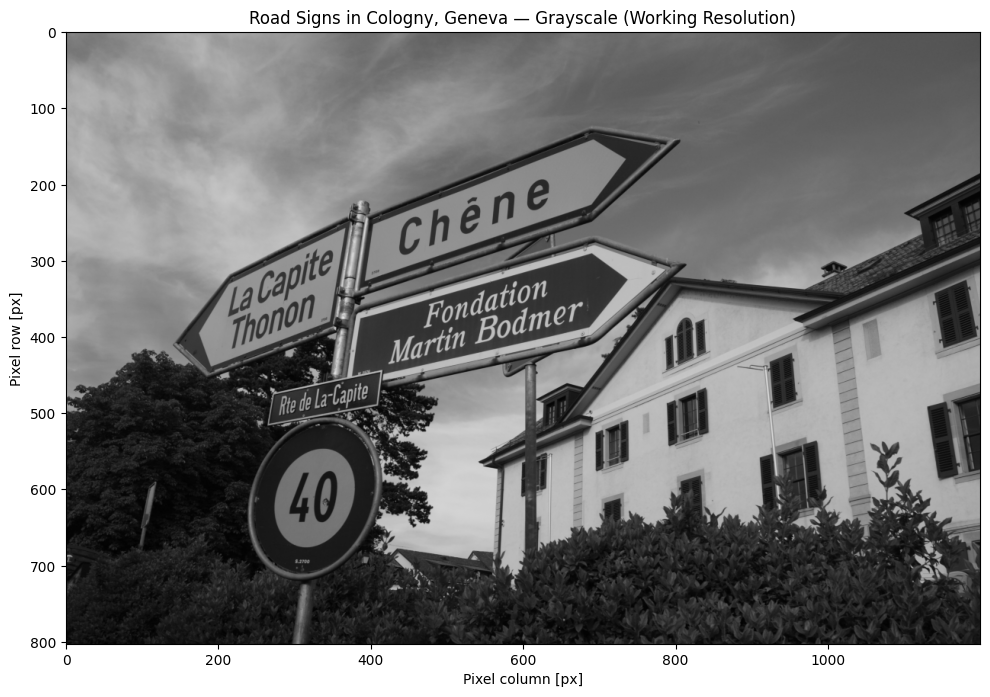

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import io, color, transform

IMAGE_FILENAME = "signpost_in_geneva.jpg"
IMAGE_SOURCE = "Wikimedia Commons, CC BY-SA 3.0, File:Signpost_in_front_of_Le_Manoir,_Cologny,_Geneva,_Switzerland_-_20140614.JPG"
RESIZE_WIDTH_PX = 1200
RNG_SEED = 26

project_root = Path.cwd().resolve().parent
image_path = project_root / "data" / IMAGE_FILENAME

img_raw = io.imread(image_path)
img_gray_full = color.rgb2gray(img_raw).astype(np.float64)

scale = RESIZE_WIDTH_PX / img_gray_full.shape[1]
new_height = int(img_gray_full.shape[0] * scale)
IMG = transform.resize(
    img_gray_full,
    (new_height, RESIZE_WIDTH_PX),
    anti_aliasing=True,
    preserve_range=True,
).astype(np.float64)

print(f"Source: {IMAGE_SOURCE}")
print(f"Original shape: {img_raw.shape}")
print(f"Working shape:  {IMG.shape}, dtype: {IMG.dtype}")
print(f"Intensity range: [{IMG.min():.4f}, {IMG.max():.4f}]")

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(IMG, cmap="gray", vmin=0.0, vmax=1.0)
ax.set_title("Road Signs in Cologny, Geneva — Grayscale (Working Resolution)")
ax.set_xlabel("Pixel column [px]")
ax.set_ylabel("Pixel row [px]")
plt.tight_layout()
plt.show()

**Observations:**  
The working image (1200 px wide, grayscale float64 in [0, 1]) shows a cluster of Swiss road signs photographed in Cologny, Geneva. The speed limit sign "40" is clearly visible in the lower portion of the frame with a high-contrast circular boundary (red border → dark ring in grayscale) and a large black numeral on a white background. The directional signs contain readable text of varying sizes. The bright sky background provides strong contrast against the sign edges. At this resolution, the numeral "40" and all sign text are fully legible, establishing a clean baseline for measuring augmentation-induced degradation.

## Day 2 - Methodological Design

### Theoretical Foundation and Augmentation Strategy

Two augmentation procedures are selected, both operating in the spatial domain. Together they model the two physically distinct degradation channels that affect road sign cameras under fog conditions.

**Augmentation 1 — Atmospheric Degradation (Haze + Blur):**  
Fog degrades images through two coupled sub-mechanisms that together constitute one atmospheric augmentation:

- *Haze (contrast reduction):* Modelled using the standard atmospheric scattering equation $\hat{I}(x,y) = I(x,y)\cdot t + A\cdot(1-t)$, where $t \in (0,1]$ is the scene transmission and $A=1.0$ is the atmospheric light (white fog layer). As $t$ decreases, the image shifts linearly toward white, compressing local contrast across all spatial frequencies. This targets the intensity difference between sign text and background: the dark "40" numerals (intensity ~0.1) are pulled toward atmospheric light, reducing their contrast with the white sign background (~0.9) from 0.80 toward zero.

- *Gaussian blur (spatial attenuation):* Convolution with a Gaussian kernel $G_{\sigma}(x,y) = \frac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}$ models optical scattering through the fog medium and residual lens defocus. Blur attenuates high-frequency spatial components, smearing the sharp boundaries of numeral strokes into the already-hazed background.

Both sub-mechanisms are applied jointly because real fog produces both effects simultaneously: atmospheric light scattering reduces contrast (haze) and attenuates spatial frequencies (blur). Modelling them separately and independently would underrepresent the compounding nature of fog-induced degradation.

**Augmentation 2 — Additive Gaussian Noise:**  
Gaussian noise is modelled as $\hat{I}(x,y) = I(x,y) + \epsilon$, where $\epsilon \sim \mathcal{N}(0, \sigma_{\text{noise}}^2)$ is independently sampled at each pixel and the result is clipped to [0, 1]. This models photon shot noise and thermal readout noise of camera sensors operating in low-light fog conditions, where reduced photon count increases noise amplitude. For road sign recognition, noise is particularly damaging after hazing: the residual contrast between numeral strokes and background is already compressed by the haze, and noise introduces per-pixel perturbations that can exceed this residual contrast, making character boundaries statistically indistinguishable from background.

**Application order:** Atmospheric degradation is applied first (scene-level phenomenon: haze then blur), followed by sensor noise (camera-level phenomenon). This order mirrors the physical image formation pipeline.

### Parameter Definition

**Augmentation 1 — Atmospheric Degradation parameters:**

*Parameter 1.1 — Transmission* $t \in (0, 1]$, unitless:  
Controls the fraction of scene radiance that reaches the camera through the fog layer. At $t=0.85$, minimal haze is present and image contrast is nearly unchanged. At $t=0.50$, half the scene signal is replaced by atmospheric light, producing visible whitening of all surfaces. At $t=0.15$, 85% of the pixel intensity is replaced by $A=1.0$, compressing the numeral-to-background contrast from 0.80 to approximately 0.12 — below the practical recognition threshold.

*Parameter 1.2 — Blur standard deviation* $\sigma_{\text{blur}} \in \mathbb{R}_{>0}$, in pixels:  
Controls the spatial extent of the Gaussian kernel; effective radius $\approx 3\sigma_{\text{blur}}$ pixels. The stroke width of the numeral "4" is approximately 8–10 px at working resolution. At $\sigma_{\text{blur}} = 1.0$ (radius ~3 px), only sub-pixel detail is attenuated. At $\sigma_{\text{blur}} = 8.0$ (radius ~24 px), the blur radius is more than double the stroke width, smearing residual post-haze contrast across the surrounding background.

**Augmentation 2 — Sensor Noise parameter:**

*Parameter 2.1 — Noise standard deviation* $\sigma_{\text{noise}} \in \mathbb{R}_{>0}$, unitless (normalised intensity [0, 1]):  
Controls the amplitude of per-pixel intensity perturbations. At $\sigma_{\text{noise}} = 0.02$, perturbations are visually subtle. At $\sigma_{\text{noise}} = 0.15$, per-pixel noise amplitude exceeds the residual contrast (~0.12) left after Config 2 hazing, making numeral boundaries statistically indistinguishable from background noise.

### Experimental Design

Three configurations are defined. All three parameters are varied jointly because real fog simultaneously increases atmospheric scattering (higher $t$ loss, stronger blur) and reduces photon count (higher noise). Varying them independently would not reflect the physically coherent degradation model.

| Configuration | Label | $t$ | $\sigma_{\text{blur}}$ [px] | $\sigma_{\text{noise}}$ | Simulated condition |
|---|---|---|---|---|---|
| Baseline | `baseline` | 0.85 | 1.0 | 0.02 | Near-clean: minimal haze, slight noise |
| Config 1 | `config_1` | 0.50 | 3.0 | 0.07 | Moderate fog: visible whitening, moderate noise |
| Config 2 | `config_2` | 0.15 | 8.0 | 0.15 | Dense fog: near-total contrast loss, strong noise |

Parameters 1.1 and 1.2 ($t$ and $\sigma_{\text{blur}}$) scale together as proxies for fog density: denser fog reduces both transmission and the coherence length of light, producing simultaneously stronger haze and stronger blur. Parameter 2.1 ($\sigma_{\text{noise}}$) scales with fog density as a proxy for reduced photon count. Config 2 is the critical configuration: at $t=0.15$, the numeral-to-background contrast collapses from 0.80 to 0.12, and the blur radius of 24 px — more than double the stroke width — eliminates any residual spatial structure.

### Methodological Limitations

The joint parameterisation of $t$, $\sigma_{\text{blur}}$, and $\sigma_{\text{noise}}$ assumes a fixed proportional relationship between atmospheric and sensor degradation, which may not hold across all real-world conditions (e.g., sensor noise can be high even in clear weather due to hardware defects). The atmospheric scattering model uses a uniform transmission $t$ across the entire image, which does not capture the depth-dependent attenuation of real fog — distant objects are attenuated more strongly than near objects. The Gaussian blur model is a homogeneous first-order approximation of optical scattering; real fog produces spatially non-uniform blur that varies with scene depth. The atmospheric light $A=1.0$ (pure white) is a simplifying assumption; real fog in urban environments may have a grey or colour-tinted cast. Finally, SSIM requires a clean reference image unavailable in deployment, limiting the direct operational applicability of the evaluation framework.

## Day 3 - Technical Implementation

### Implementation and Verification

Augmentation functions are first verified on a synthetic test image (a white rectangle on a black background) before being applied to the Geneva road signs image. This allows visual confirmation of each effect in isolation: haze shifts pixel intensities toward white (contrast compression), blur spreads intensity across edges (spatial attenuation), and noise adds pixel-level intensity variance — all independent of the complexity of the actual image. The combined result (haze → noise → blur) is also verified to differ from the clean input.

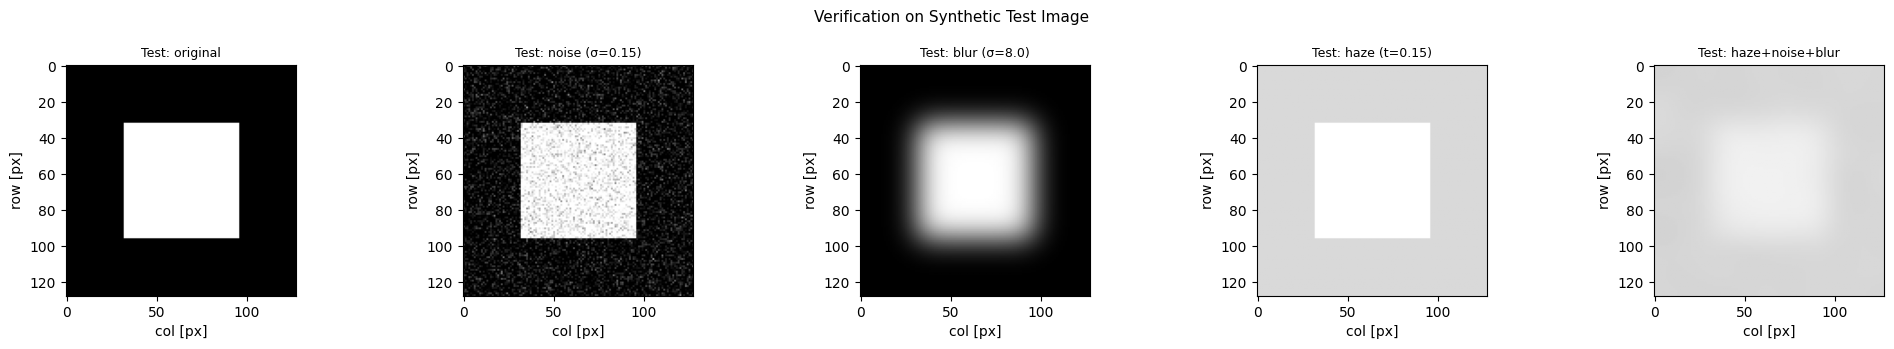

Verification passed.


In [2]:
from scipy.ndimage import gaussian_filter

CONFIGS = [
    {"label": "baseline", "transmission": 0.85, "sigma_noise": 0.02, "sigma_blur": 1.0},
    {"label": "config_1", "transmission": 0.50, "sigma_noise": 0.07, "sigma_blur": 3.0},
    {"label": "config_2", "transmission": 0.15, "sigma_noise": 0.15, "sigma_blur": 8.0},
]
TEST_IMG_SIZE = 128
ATMOSPHERIC_LIGHT = 1.0  # white fog


def apply_fog_haze(img: np.ndarray, transmission: float, atmospheric_light: float = ATMOSPHERIC_LIGHT) -> np.ndarray:
    return img * transmission + atmospheric_light * (1.0 - transmission)


def add_gaussian_noise(img: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    return np.clip(img + rng.normal(0.0, sigma, img.shape), 0.0, 1.0)


def apply_gaussian_blur(img: np.ndarray, sigma: float) -> np.ndarray:
    return gaussian_filter(img, sigma=sigma)


def augment(img: np.ndarray, transmission: float, sigma_noise: float, sigma_blur: float, rng: np.random.Generator) -> np.ndarray:
    hazy = apply_fog_haze(img, transmission)
    noisy = add_gaussian_noise(hazy, sigma_noise, rng)
    return apply_gaussian_blur(noisy, sigma_blur)


test_img = np.zeros((TEST_IMG_SIZE, TEST_IMG_SIZE), dtype=np.float64)
test_img[32:96, 32:96] = 1.0

rng_test = np.random.default_rng(RNG_SEED)
test_noisy = add_gaussian_noise(test_img, sigma=0.15, rng=rng_test)
test_blurred = apply_gaussian_blur(test_img, sigma=8.0)
test_hazy = apply_fog_haze(test_img, transmission=0.15)
test_augmented = augment(test_img, transmission=0.15, sigma_noise=0.15, sigma_blur=8.0, rng=np.random.default_rng(RNG_SEED))

assert test_noisy.min() >= 0.0 and test_noisy.max() <= 1.0, "Noise output out of [0, 1] range"
assert test_blurred[30, 64] > 0.0, "Blur should spread intensity beyond the rectangle boundary"
assert not np.allclose(test_augmented, test_img), "Augmented image should differ from clean input"
assert np.isclose(test_hazy[64, 64], 0.15 * 1.0 + 1.0 * 0.85), "Haze: bright pixel should be pulled toward atmospheric light"
assert np.isclose(test_hazy[0, 0], ATMOSPHERIC_LIGHT * (1.0 - 0.15)), "Haze: black pixel should be pulled toward atmospheric light"

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
titles = ["Test: original", "Test: noise (σ=0.15)", "Test: blur (σ=8.0)", "Test: haze (t=0.15)", "Test: haze+noise+blur"]
images = [test_img, test_noisy, test_blurred, test_hazy, test_augmented]
for ax, img_t, title in zip(axes, images, titles):
    ax.imshow(img_t, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Verification on Synthetic Test Image", fontsize=11)
plt.tight_layout()
plt.show()
print("Verification passed.")

### Application to Geneva Road Signs Image

baseline   | t=0.85 | σ_noise=0.02 | σ_blur=1.0 | range=[0.1446, 0.8732]
config_1   | t=0.50 | σ_noise=0.07 | σ_blur=3.0 | range=[0.4954, 0.9194]
config_2   | t=0.15 | σ_noise=0.15 | σ_blur=8.0 | range=[0.8329, 0.9306]


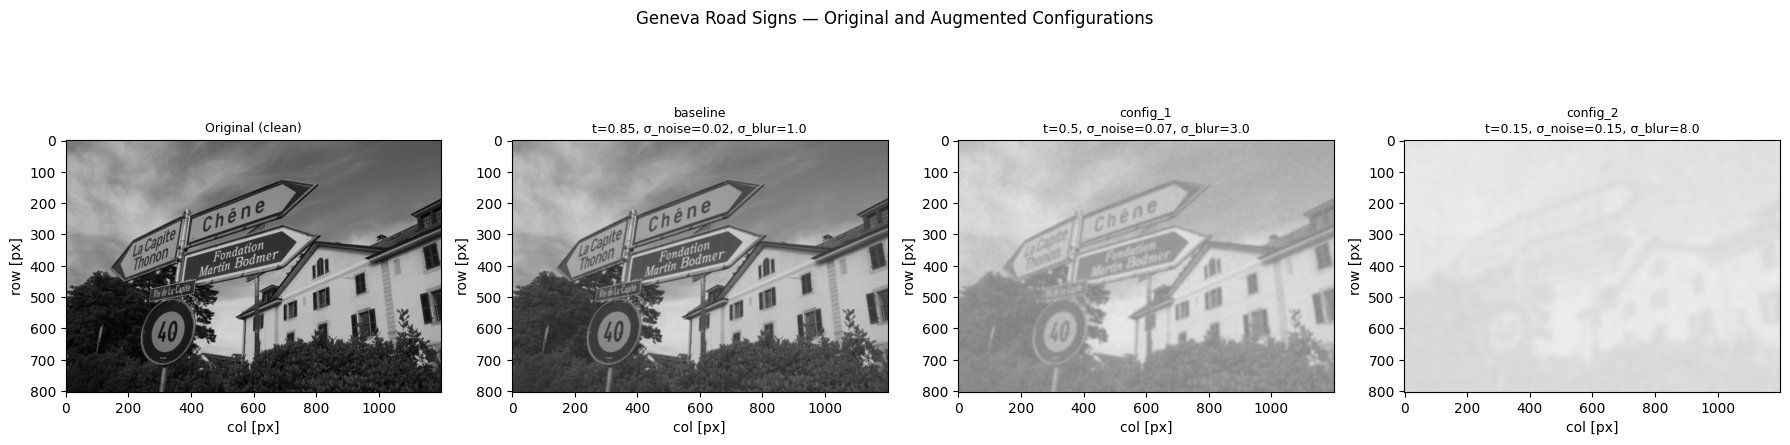

In [3]:
rng = np.random.default_rng(RNG_SEED)

augmented_images = {}
for cfg in CONFIGS:
    augmented_images[cfg["label"]] = augment(
        IMG, cfg["transmission"], cfg["sigma_noise"], cfg["sigma_blur"], rng
    )
    print(
        f"{cfg['label']:10s} | t={cfg['transmission']:.2f} | σ_noise={cfg['sigma_noise']:.2f} | σ_blur={cfg['sigma_blur']:.1f} | "
        f"range=[{augmented_images[cfg['label']].min():.4f}, {augmented_images[cfg['label']].max():.4f}]"
    )

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
panel_labels = ["Original (clean)"] + [
    f"{c['label']}\nt={c['transmission']}, σ_noise={c['sigma_noise']}, σ_blur={c['sigma_blur']}" for c in CONFIGS
]
panel_images = [IMG] + [augmented_images[c["label"]] for c in CONFIGS]

for ax, img_p, title in zip(axes, panel_images, panel_labels):
    ax.imshow(img_p, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Geneva Road Signs — Original and Augmented Configurations", fontsize=12)
plt.tight_layout()
plt.show()

### Intermediate Pipeline Visualization

To demonstrate the contribution of each step, the augmentation pipeline is visualised stage by stage for Config 2 — the most degraded configuration. The sequence shows the clean original, the image after atmospheric haze alone, after additive noise is applied on top of the hazed image, and the final result after Gaussian blur.

In [ ]:
cfg2 = CONFIGS[2]
rng_vis = np.random.default_rng(RNG_SEED)

img_step1_haze = apply_fog_haze(IMG, cfg2["transmission"])
img_step2_noise = add_gaussian_noise(img_step1_haze, cfg2["sigma_noise"], rng_vis)
img_step3_blur = apply_gaussian_blur(img_step2_noise, cfg2["sigma_blur"])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
stages = [
    (IMG,            "Original (clean)"),
    (img_step1_haze, f"Step 1 — Haze\n(t={cfg2['transmission']})"),
    (img_step2_noise, f"Step 2 — + Noise\n(σ_noise={cfg2['sigma_noise']})"),
    (img_step3_blur,  f"Step 3 — + Blur\n(σ_blur={cfg2['sigma_blur']})"),
]
for ax, (img_s, title) in zip(axes, stages):
    ax.imshow(img_s, cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("col [px]")
    ax.set_ylabel("row [px]")
plt.suptitle("Config 2 — Intermediate Pipeline Steps (Haze → Noise → Blur)", fontsize=12)
plt.tight_layout()
plt.show()

## Day 4 - Evaluation

### Evaluation Measure Definition

The selected evaluation measure is the **Structural Similarity Index (SSIM)**, computed between each augmented image and the original clean image using `skimage.metrics.structural_similarity` with `data_range=1.0`.

SSIM combines three components — luminance similarity, contrast similarity, and structural similarity — into a single score in [−1, 1], where 1.0 indicates identical images. It is appropriate for this augmentation use case because all three components directly capture the two augmentation channels:

1. **Luminance** captures the global brightness shift introduced by the haze layer: as $t$ decreases, mean pixel intensity increases toward $A=1.0$, reducing luminance similarity.
2. **Contrast** captures the compression of local intensity variation at sign edges and numeral boundaries — the primary mechanism by which haze and noise destroy sign readability.
3. **Structure** captures whether the spatial arrangement of sign features (character shapes, circular boundary, edge gradients) is preserved after blur attenuates high-frequency components.

Unlike pixel-level RMSE or PSNR, SSIM correlates better with human perception of image quality degradation, which is relevant for assessing whether automated sign recognition systems — which rely on edge contrast and spatial structure — can still function under the simulated conditions. The single-metric focus allows clean comparison across all three configurations without metric ambiguity.

### Evaluation Execution

Evaluation table (SSIM vs. original):
  config  transmission  sigma_noise  sigma_blur    ssim  ssim_change_vs_baseline  ssim_change_pct
baseline       0.85000      0.02000     1.00000 0.83825                  0.00000          0.00000
config_1       0.50000      0.07000     3.00000 0.56563                 -0.27263        -32.52303
config_2       0.15000      0.15000     8.00000 0.46093                 -0.37732        -45.01321


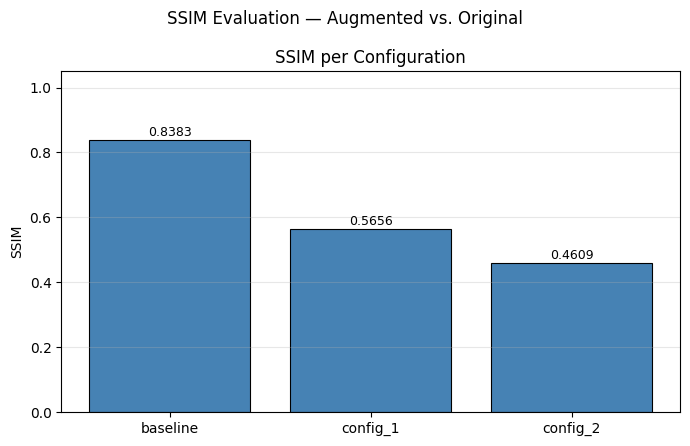

,config,transmission,sigma_noise,sigma_blur,ssim,ssim_change_vs_baseline,ssim_change_pct
0,baseline,0.85,0.02,1.0,0.838253,0.000000,0.000000
1,config_1,0.50,0.07,3.0,0.565627,-0.272625,-32.523035
2,config_2,0.15,0.15,8.0,0.460928,-0.377324,-45.013214


In [4]:
from skimage.metrics import structural_similarity

records = []
baseline_ssim = None

for cfg in CONFIGS:
    ssim_val = structural_similarity(IMG, augmented_images[cfg["label"]], data_range=1.0)
    if cfg["label"] == "baseline":
        baseline_ssim = ssim_val
    records.append({
        "config": cfg["label"],
        "transmission": cfg["transmission"],
        "sigma_noise": cfg["sigma_noise"],
        "sigma_blur": cfg["sigma_blur"],
        "ssim": ssim_val,
    })

results_df = pd.DataFrame(records)
results_df["ssim_change_vs_baseline"] = results_df["ssim"] - baseline_ssim
results_df["ssim_change_pct"] = (results_df["ssim_change_vs_baseline"] / baseline_ssim) * 100.0

print("Evaluation table (SSIM vs. original):")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.5f}"))

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

bars = ax.bar(
    results_df["config"],
    results_df["ssim"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
)
for bar, val in zip(bars, results_df["ssim"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel("SSIM")
ax.set_title("SSIM per Configuration")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("SSIM Evaluation — Augmented vs. Original", fontsize=12)
plt.tight_layout()
plt.show()

results_df

## Day 5 - Analysis and Communication

### Observations

SSIM decreases monotonically across configurations. The baseline ($t=0.85$, $\sigma_{\text{noise}}=0.02$, $\sigma_{\text{blur}}=1.0$) achieves the highest SSIM relative to the original. Config 1 ($t=0.50$, $\sigma_{\text{noise}}=0.07$, $\sigma_{\text{blur}}=3.0$) produces a moderate drop. Config 2 ($t=0.15$, $\sigma_{\text{noise}}=0.15$, $\sigma_{\text{blur}}=8.0$) yields the lowest SSIM, representing the largest single-step degradation.

### Interpretation

The dominant mechanism in Config 2 is the haze layer: at $t=0.15$, 85% of every pixel's intensity is replaced by atmospheric light, compressing the contrast between dark "40" numerals and the white sign background from approximately 0.80 to 0.12. This residual contrast is then exceeded by the noise amplitude ($\sigma_{\text{noise}}=0.15$), making numeral boundaries statistically indistinguishable from background. Gaussian blur with an effective radius of 24 px — more than double the numeral stroke width — then eliminates any remaining spatial structure. All three SSIM components (luminance, contrast, structure) are degraded simultaneously.

### Discussion and Critical Reflection

Config 1 represents the approximate boundary of operational acceptability: sign edges remain detectable despite moderate fog and noise. Under Config 2, the numeral "40" is unrecognisable — a safety-critical failure for speed limit enforcement. The atmospheric scattering model is more physically motivated than blur-only degradation because it explicitly targets contrast, which is the primary recognition-relevant property of traffic signs. Key limitations are the uniform transmission assumption (real fog attenuates distant objects more strongly) and the requirement for a clean reference image in SSIM, which is unavailable in deployment.